In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import random


In [2]:
# Load dataset
(X_train, Y_train), (X_test, Y_test) = fashion_mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape : (10000, 28, 28)


In [3]:
#Preprocess Data
X_train = X_train / 255.0
X_test = X_test / 255.0

# reshape (add channel)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [7]:
#Build Cnn model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')   # 10 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


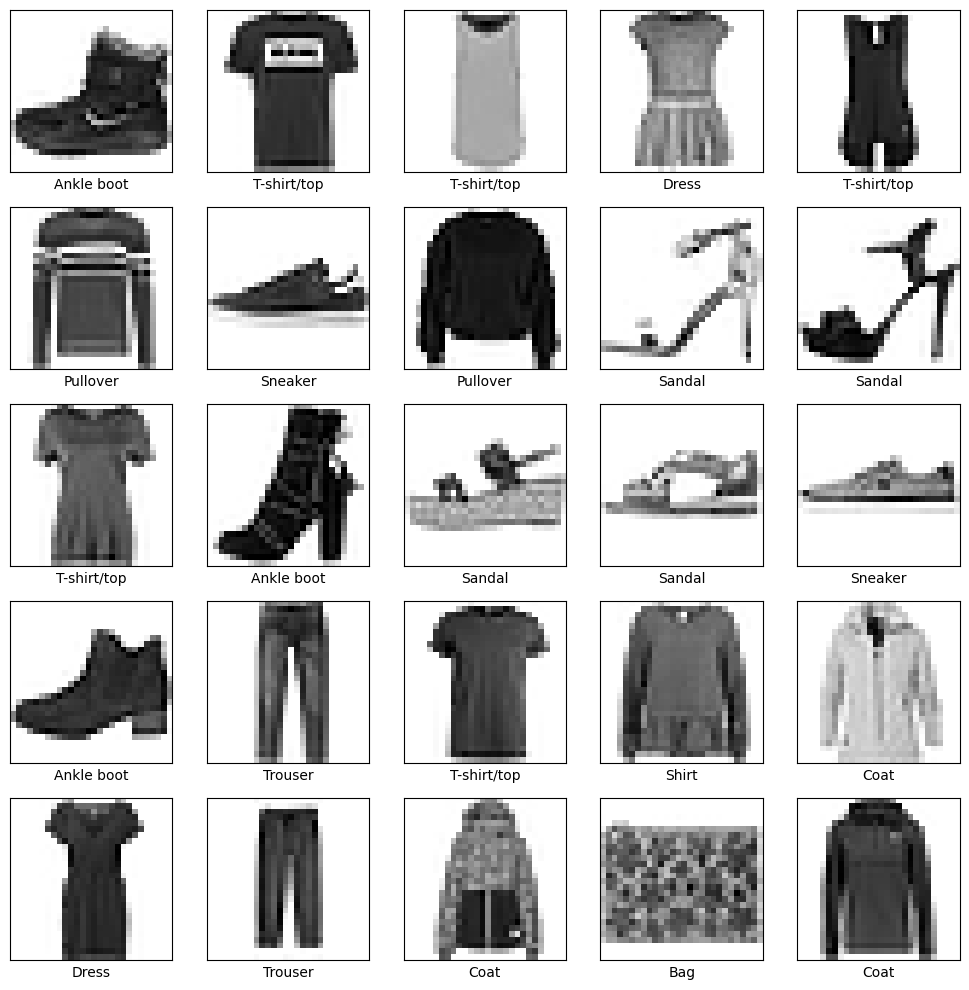

In [6]:
# Normalize data
train_norm = X_train.astype('float32') / 255.0
test_norm = X_test.astype('float32') / 255.0
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


# Display first 25 images
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_norm[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[Y_train[i]])

plt.tight_layout()
plt.show()

In [8]:
#Compile Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
#Train Model
history = model.fit(X_train, Y_train, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 27ms/step - accuracy: 0.8205 - loss: 0.5021 - val_accuracy: 0.8692 - val_loss: 0.3658
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 27ms/step - accuracy: 0.8799 - loss: 0.3302 - val_accuracy: 0.8831 - val_loss: 0.3218
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.8971 - loss: 0.2833 - val_accuracy: 0.8930 - val_loss: 0.2922
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9094 - loss: 0.2483 - val_accuracy: 0.9045 - val_loss: 0.2707
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9176 - loss: 0.2255 - val_accuracy: 0.9067 - val_loss: 0.2625


In [10]:
#Evaluate Model
loss, acc = model.evaluate(X_test, Y_test)
print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9003 - loss: 0.2742
Accuracy: 0.9003000259399414


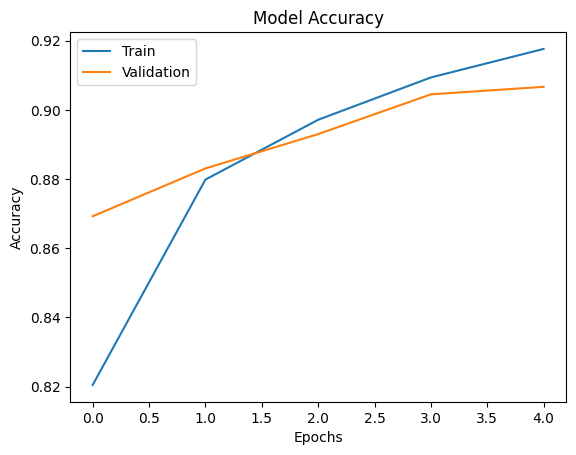

In [11]:
#Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [12]:
#Predict Example
pred = model.predict(X_test[:5])
print("Predicted classes:", pred.argmax(axis=1))
print("Actual classes:   ", Y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Predicted classes: [9 2 1 1 6]
Actual classes:    [9 2 1 1 6]


In [13]:
labels = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
          "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


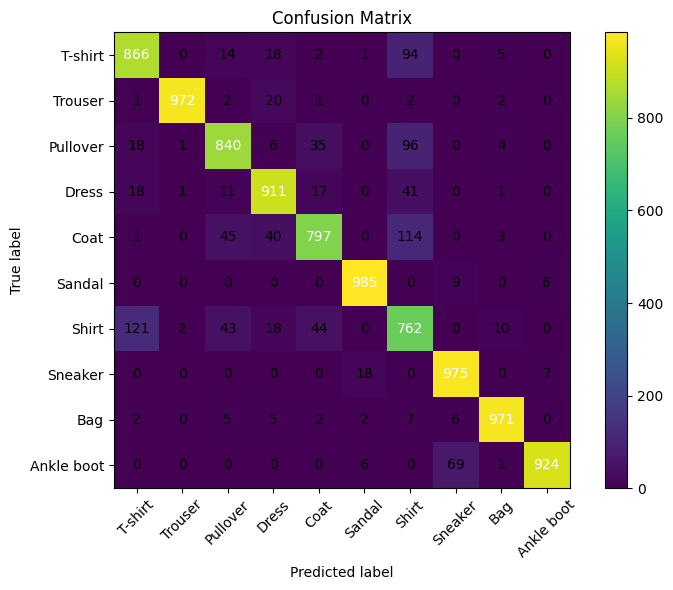

In [14]:
# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_classes)

# Plot
plt.figure(figsize=(8,6))
plt.imshow(cm)

plt.title("Confusion Matrix")
plt.colorbar()

# Axis labels
plt.xticks(range(10), labels, rotation=45)
plt.yticks(range(10), labels)

plt.xlabel("Predicted label")
plt.ylabel("True label")

# Add numbers inside boxes
for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()

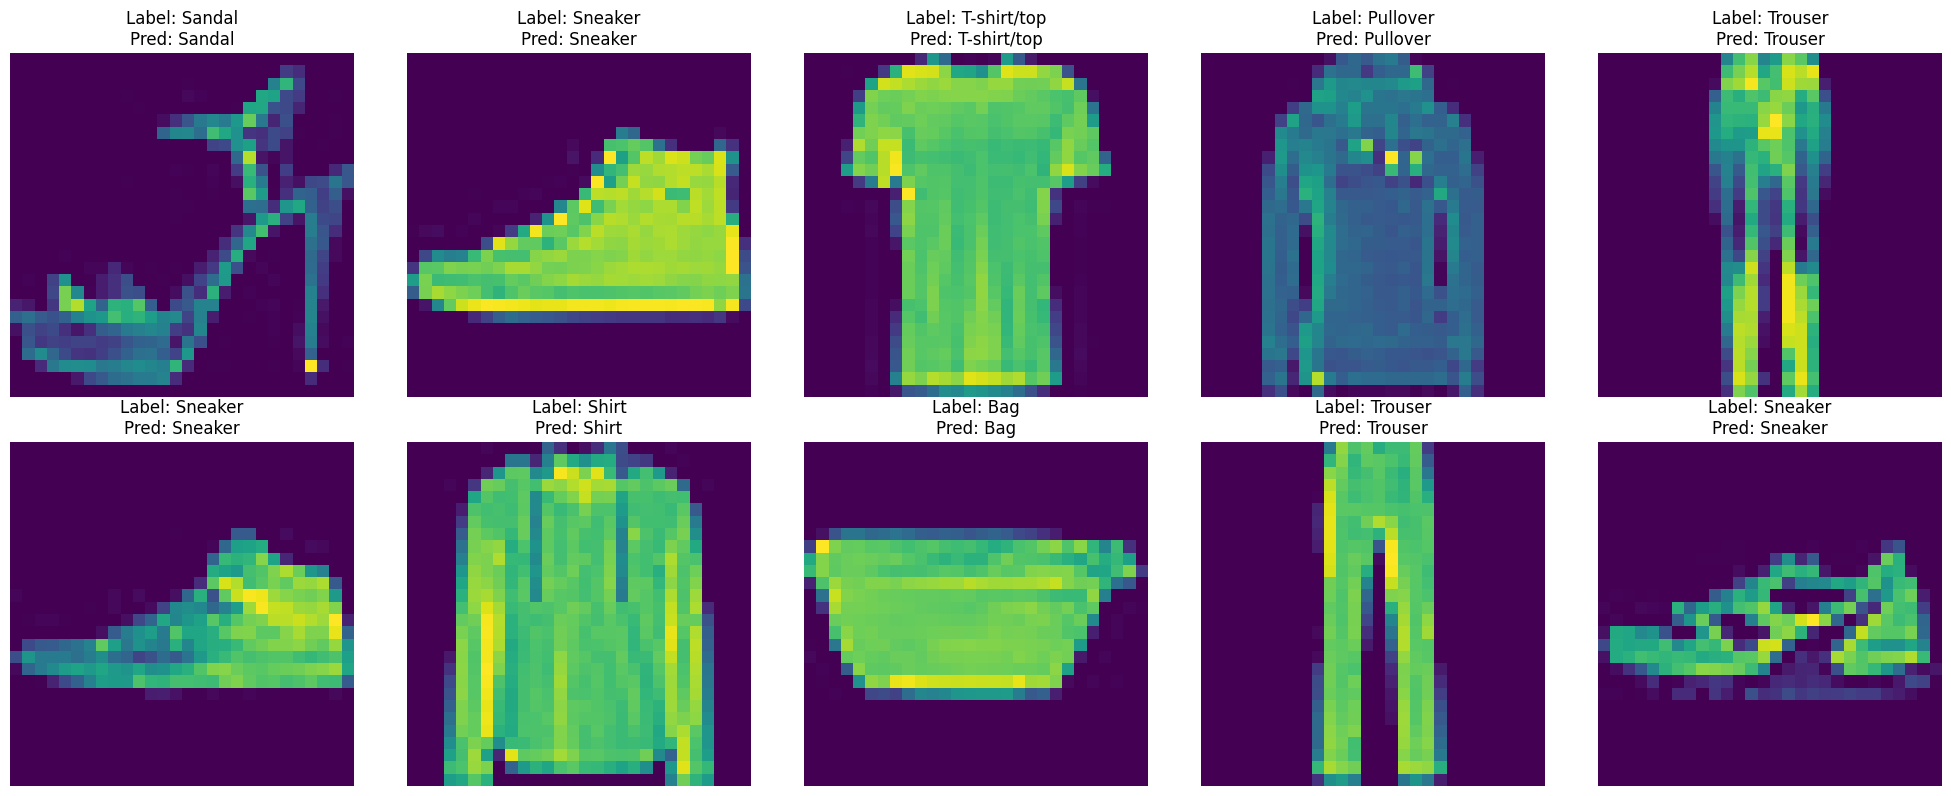

In [15]:
# Class names
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

images = []
labels = []

# Pick 10 random test images
random_indices = random.sample(range(len(X_test)), 10)

for idx in random_indices:
    images.append(X_test[idx])
    labels.append(Y_test[idx])

images = np.array(images)
labels = np.array(labels)

# Plot
plt.figure(figsize=(20, 8))
rows, cols = 2, 5

for i in range(10):
    plt.subplot(rows, cols, i+1)

    # Prediction
    img = np.expand_dims(images[i], axis=0)
    pred = model.predict(img, verbose=0)
    pred_label = np.argmax(pred)

    # Show image
    plt.imshow(images[i].reshape(28,28), cmap='viridis')

    # Title (Actual vs Prediction)
    plt.title(f"Label: {class_names[labels[i]]}\nPred: {class_names[pred_label]}")

    plt.axis("off")

plt.tight_layout()
plt.show()